In [1]:
import numpy as np
import pandas as pd
import os

import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from joblib import dump, load

import matplotlib.pyplot as plt
import seaborn as sns

c:\anaconda\envs\mi_entorno\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Rutas y parámetros globales

In [2]:
BASE_DIR = '../'

PATH_TRAIN_CLEAN = os.path.join(BASE_DIR, 'work/cleaned/train_clean.csv')
PATH_TEST_CLEAN  = os.path.join(BASE_DIR, 'work/cleaned/test_clean.csv')

PATH_TO_MODELS   = os.path.join(BASE_DIR, 'work/models')
os.makedirs(PATH_TO_MODELS, exist_ok=True)

SEED   = 42
N_FOLDS = 5
TARGET  = 'AdoptionSpeed'

---
## 3. Carga de datos limpios

In [3]:
train = pd.read_csv(PATH_TRAIN_CLEAN)
test  = pd.read_csv(PATH_TEST_CLEAN)

print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')
train.head()

Train shape: (11994, 26)
Test  shape: (2999, 26)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,has_name,has_description
0,1,The Adorable Trio,2.0,307,307,1,1,0,0,2,...,0,41326,ba248f761903dcd4c4342cc724a52145,0,These 3 puppies was rescued from a mechanic sh...,23b64fe21,8.0,2,1,1
1,1,Perky,12.0,307,0,2,2,0,0,1,...,0,41326,744fa4278196568a18fcf5cd7d324ed2,0,Rescued from the dog pound. Great survivor. Ve...,6e09bfe1f,3.0,3,1,1
2,1,Bernard Boy,2.0,307,307,1,1,2,7,2,...,0,41326,4d2400be2e2e78265f5c84345b7a3415,0,"Location : Teluk Intan, Perak",48a44eac5,1.0,4,1,1
3,1,Oreo 1,2.0,307,307,1,3,0,0,2,...,0,41326,b53c34474d9e24574bcec6a3d3306a0d,0,for Adoption,ae219ff80,2.0,1,1,1
4,2,Anak Kucing,4.0,265,0,3,1,2,0,2,...,0,41326,b953d651238f379c63e732925f71a5a2,0,Kittens for adoption,e13c47053,2.0,2,1,1


---
## 4. Feature Engineering

### 4.1 Columnas a descartar

- `PetID` — identificador único, sin valor predictivo  
- `RescuerID` — alta cardinalidad (~4000 rescatadores), riesgo de sobreajuste  
- `Name`, `Description` — texto libre; ya capturado por los flags `has_name` / `has_description`

In [4]:
# desc_len se calcula aquí, antes de descartar la columna Description
for df in [train, test]:
    df['desc_len'] = df['Description'].fillna('').str.split().str.len()

DROP_COLS = ['PetID', 'RescuerID', 'Name', 'Description']

train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)

print(f'Columnas tras descarte: {train.shape[1]}')

Columnas tras descarte: 22


### 4.2 Feature derivada: `health_score`

Suma de indicadores de salud documentados (cada uno vale 1 si está completo/positivo):  
`Vaccinated==1`, `Dewormed==1`, `Sterilized==1`, `Health==1`

In [5]:
for df in [train, test]:
    df['health_score'] = (
        (df['Vaccinated']  == 1).astype(int) +
        (df['Dewormed']    == 1).astype(int) +
        (df['Sterilized']  == 1).astype(int) +
        (df['Health']      == 1).astype(int)
    )

print(train['health_score'].value_counts().sort_index())

health_score
0     195
1    4720
2    2364
3    2801
4    1914
Name: count, dtype: int64


### 4.3 Feature derivada: `desc_len`

Largo en palabras de la descripción original.  
Se calcula antes de descartar la columna `Description`, evitando releer el CSV.

In [6]:
print(f"desc_len — train media: {train['desc_len'].mean():.1f} palabras")

### 4.4 Encoding de variables categóricas

LightGBM puede manejar categorías nativas, pero requiere tipo `category` explícito.  
Se usa `LabelEncoder` ajustado sobre train y aplicado a test.

Columnas a encodear: `Type`, `Gender`, `Color1`, `Color2`, `Color3`, `MaturitySize`, `FurLength`, `Vaccinated`, `Dewormed`, `Sterilized`, `Health`, `Breed1`, `Breed2`, `State`

In [7]:
CAT_COLS = ['Type', 'Gender', 'Color1', 'Color2', 'Color3',
            'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
            'Sterilized', 'Health', 'Breed1', 'Breed2', 'State']

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    # Valores en test no vistos en train → mapear a 0 (categoría más frecuente)
    test[col] = test[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else 0
    )
    encoders[col] = le

dump(encoders, os.path.join(PATH_TO_MODELS, 'label_encoders.joblib'))
print('Encoding completo. Encoders guardados.')
print(f'Columnas finales: {train.shape[1]}')

Encoding completo.
Columnas finales: 24


---
## 5. Definición de X e y

In [8]:
FEATURE_COLS = [c for c in train.columns if c != TARGET]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]

X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f'Features: {len(FEATURE_COLS)}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Clases: {sorted(y_train.unique())}')

Features: 23
X_train: (11994, 23) | X_test: (2999, 23)
Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


---
## 6. Modelo baseline — LightGBM + StratifiedKFold

Primer entrenamiento con parámetros por defecto para obtener una línea base.  
Métrica principal: **Cohen's Kappa** (penaliza el azar y maneja el desbalance de clases).

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

kappa_folds = []
acc_folds   = []

base_params = {
    'objective':   'multiclass',
    'num_class':   5,
    'metric':      'multi_logloss',
    'verbosity':   -1,
    'random_state': SEED,
    'class_weight': 'balanced', 
}

for fold, (idx_tr, idx_val) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
    y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]

    model = lgb.LGBMClassifier(**base_params, n_estimators=500)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )

    preds = model.predict(X_val)
    kappa = cohen_kappa_score(y_val, preds, weights='quadratic')
    acc   = accuracy_score(y_val, preds)

    kappa_folds.append(kappa)
    acc_folds.append(acc)
    print(f'  Fold {fold} — Kappa: {kappa:.4f}  Acc: {acc:.4f}')

print(f'\nBaseline — Kappa medio: {np.mean(kappa_folds):.4f} ± {np.std(kappa_folds):.4f}')
print(f'Baseline — Acc media:   {np.mean(acc_folds):.4f} ± {np.std(acc_folds):.4f}')

  Fold 1 — Kappa: 0.3682  Acc: 0.4206
  Fold 2 — Kappa: 0.3587  Acc: 0.4152
  Fold 3 — Kappa: 0.3454  Acc: 0.4089
  Fold 4 — Kappa: 0.3596  Acc: 0.4056
  Fold 5 — Kappa: 0.3480  Acc: 0.4158

Baseline — Kappa medio: 0.3560 ± 0.0083
Baseline — Acc media:   0.4132 ± 0.0053


---
## 7. Tuneo de hiperparámetros con Optuna

Se optimizan los hiperparámetros más influyentes de LightGBM usando Optuna con `TPESampler` (Bayesian).  
La métrica a maximizar es el **Kappa cuadrático medio** sobre los N_FOLDS.

In [10]:
def objective(trial):
    params = {
        'objective':        'multiclass',
        'num_class':        5,
        'metric':           'multi_logloss',
        'verbosity':        -1,
        'random_state':     SEED,
        'class_weight':     'balanced',
        'n_estimators':     500,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 100),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    kappas = []
    for idx_tr, idx_val in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
        y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]

        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        preds = m.predict(X_val)
        kappas.append(cohen_kappa_score(y_val, preds, weights='quadratic'))

    return np.mean(kappas)


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'
Mejor Kappa: {study.best_value:.4f}')
print(f'Mejores params: {study.best_params}')

Best trial: 27. Best value: 0.359384: 100%|██████████| 50/50 [11:41<00:00, 14.04s/it]


Mejor Kappa: 0.3594
Mejores params: {'learning_rate': 0.0625284805165965, 'num_leaves': 90, 'max_depth': 7, 'min_child_samples': 42, 'subsample': 0.932475343184881, 'colsample_bytree': 0.8830508376250706, 'reg_alpha': 0.0005649715583345482, 'reg_lambda': 0.00022579208325434623}


---
## 8. Evaluación final sobre test

Se entrena el modelo final con los mejores hiperparámetros usando un **90% del train** con early stopping sobre el **10% restante** (split estratificado), y se evalúa sobre el test (nunca visto).

In [ ]:
from sklearn.model_selection import train_test_split

best_params = {
    'objective':    'multiclass',
    'num_class':    5,
    'metric':       'multi_logloss',
    'verbosity':    -1,
    'random_state': SEED,
    'n_estimators': 1000,
    'class_weight': 'balanced',
    **study.best_params
}

# Split estratificado para early stopping — el test nunca se usa aquí
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    X_tr_final, y_tr_final,
    eval_set=[(X_val_final, y_val_final)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

# Guardar modelo
dump(final_model, os.path.join(PATH_TO_MODELS, 'lgbm_final.joblib'))
print('Modelo guardado.')

In [12]:
y_pred = final_model.predict(X_test)

kappa   = cohen_kappa_score(y_test, y_pred, weights='quadratic')
acc     = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print('=== Métricas sobre test ===')
print(f'  Cohen Kappa (quadratic): {kappa:.4f}')
print(f'  Accuracy:                {acc:.4f}')
print(f'  Balanced Accuracy:       {bal_acc:.4f}')

=== Métricas sobre test ===
  Cohen Kappa (quadratic): 0.3115
  Accuracy:                0.3925
  Balanced Accuracy:       0.3354


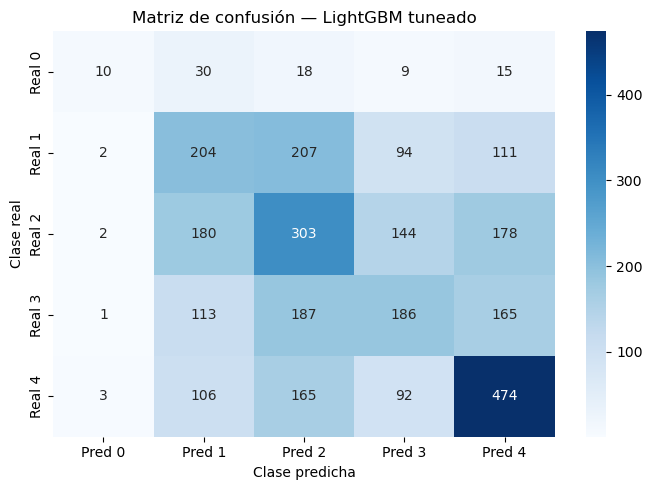

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'Pred {i}' for i in range(5)],
    yticklabels=[f'Real {i}' for i in range(5)]
)
plt.title('Matriz de confusión — LightGBM tuneado')
plt.ylabel('Clase real')
plt.xlabel('Clase predicha')
plt.tight_layout()
plt.show()

C:\Users\Hp EliteBook\AppData\Local\Temp\ipykernel_6520\2267521190.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')


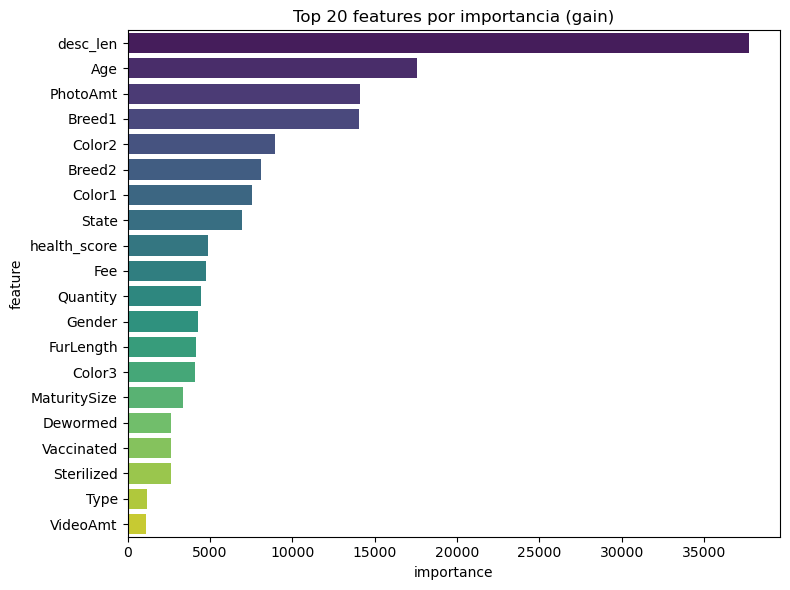

In [15]:
importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 features por importancia (gain)')
plt.tight_layout()
plt.show()